   userId  movieId  rating  liked
0       1       16     4.0      1
1       1       24     1.5      0
2       1       32     4.0      1
3       1       47     4.0      1
4       1       50     4.0      1
Train : (84271, 2) | Test : (21068, 2)
Accuracy SVM : 0.6187

Rapport de classification :
              precision    recall  f1-score   support

           0       0.63      0.06      0.11      8236
           1       0.62      0.98      0.76     12832

    accuracy                           0.62     21068
   macro avg       0.62      0.52      0.43     21068
weighted avg       0.62      0.62      0.50     21068



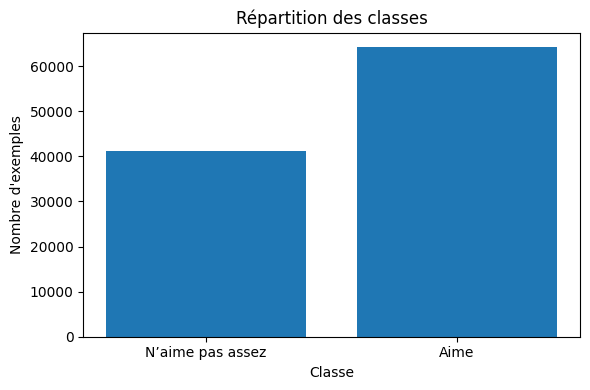

svm_model.pkl et svm_scaler.pkl sauvegardés avec succès


In [7]:


import numpy as np
import pickle
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

df= ratings.merge(movies, on='movieId')

# 1. Créer une cible binaire
# 1 = aime le film, 0 = n'aime pas assez
df_svm = df.copy()
df_svm['liked'] = (df_svm['rating'] >= 3.5).astype(int)

print(df_svm[['userId', 'movieId', 'rating', 'liked']].head())

# 2. Features simples
X_svm = df_svm[['userId', 'movieId']].values
y_svm = df_svm['liked'].values

# 3. Séparer train / test
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_svm, y_svm, test_size=0.2, random_state=42, stratify=y_svm
    )

    # 4. Normaliser
scaler_svm = StandardScaler()
X_train_svm = scaler_svm.fit_transform(X_train_svm)
X_test_svm = scaler_svm.transform(X_test_svm)

print(f"Train : {X_train_svm.shape} | Test : {X_test_svm.shape}")

    # 5. Entraîner le modèle SVM
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train_svm, y_train_svm)

    # 6. Prédictions
y_pred_svm = svm_model.predict(X_test_svm)

    # 7. Évaluation
accuracy_svm = accuracy_score(y_test_svm, y_pred_svm)
print(f"Accuracy SVM : {accuracy_svm:.4f}")

print("\nRapport de classification :")
print(classification_report(y_test_svm, y_pred_svm))

    # 8. Petit graphique simple
classes = ['N’aime pas assez', 'Aime']
counts = df_svm['liked'].value_counts().sort_index()

plt.figure(figsize=(6,4))
plt.bar(classes, counts)
plt.title("Répartition des classes")
plt.xlabel("Classe")
plt.ylabel("Nombre d'exemples")
plt.tight_layout()
plt.show()

    # 9. Sauvegarder le modèle
with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

with open('svm_scaler.pkl', 'wb') as f:
    pickle.dump(scaler_svm, f)
    print("svm_model.pkl et svm_scaler.pkl sauvegardés avec succès")